# 13 - Node Embeddings and Link Prediction

This notebook learns a 64-dimensional vector representation (embedding) for every station in the trip-adjacency graph of Israel's public transport, and then puts those vectors to two tasks: link prediction (can we predict which pairs of stations are connected by a service segment?) and critical-station classification (do the embeddings encode structural criticality?). It also proposes new connections and tests whether adding them actually makes the network more resilient.

The heart of this notebook is a methodological fix. An earlier version of this pipeline trained Node2Vec on the full graph and then evaluated link prediction on edges that had been held out for testing - except those edges were still present while the embeddings were being learned. The model had effectively already seen the answers. The resulting AUC of 0.9928 (against 0.63-0.83 for classical metrics) is a leakage artifact, not a result. Here we split the edges first, train the embeddings only on the training graph, and report the honest number alongside the leaked one.

**Research questions**
1. How well can we predict the missing service segments in the transport graph, using local structural metrics versus learned embeddings?
2. How much of the embeddings' previously reported advantage survives a leakage-free evaluation?
3. Do new links suggested by the embeddings measurably improve the network's resilience?
4. Can node embeddings alone identify structurally critical stations?

**Input**
- `outputs/nb/02_graph_construction/` - the undirected trip-adjacency graph (pickle, or `nodes.csv` + `edges.csv`).
- Fallback if step 02 wasn't run: the raw GTFS feed in `israel-public-transportation/` along with `stop_times.txt` (816 MB, downloaded on demand). The notebook then rebuilds the graph itself, so it's fully self-contained.

**Output** (all under `outputs/nb/13_embeddings_link_prediction/`)
- `tables/link_prediction_results.csv` - AUC / average precision per method, tagged `corrected` or `leaked`.
- `tables/link_prediction_hard_negatives.csv` - the same methods against harder negative pairs (2 steps apart).
- `tables/top_k_suggested_links.csv` - the top 20 proposed new connections, ranked globally.
- `tables/resilience_improvement.csv` and `tables/resilience_improvement.json` - resilience before and after (a null result).
- `tables/critical_classifier_results.csv` - the classifier's scores (a negative result).
- `tables/station_similarity.csv` - the nearest stations in embedding space.
- `embeddings_full_graph.npz`, `embeddings_train_graph.npz` - the two embedding matrices.
- `figures/*.png` - method comparison, a map of the proposed links, resilience, confusion matrices, and t-SNE and PCA views.

## Setting up the working environment

Locates the repository (or clones it when running on Google Colab), makes sure the working directory is the repo root, and creates the notebook's output folder tree. Safe to re-run.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

if sys.version_info >= (3, 14):
    raise RuntimeError(
        f"Python {sys.version.split()[0]} is not supported by this project's scientific stack. "
        "In VS Code, click the notebook kernel and select "
        "'Python 3.10 (Israel Transit Project)', then restart the kernel."
    )
print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Libraries

We need the usual scientific toolkit, plus `gensim` (skip-gram Word2Vec, the mechanism that turns random walks into embeddings) and optionally the `node2vec` package. `node2vec` is optional on purpose: it's a thin wrapper around `gensim`, it breaks now and then against new versions of `scipy`/`gensim`, and with `p = q = 1` (the setting the original pipeline used) its second-order walks reduce exactly to ordinary first-order weighted random walks, which we can generate ourselves in a few lines. If the package isn't available we fall back to the built-in walk generator and the model stays the same.

In [2]:
_ensure("numpy", "pandas", "networkx", "scikit-learn", "matplotlib", "seaborn", "gensim")
try:
    _ensure("node2vec")
    HAS_NODE2VEC = True
except Exception as exc:
    print("node2vec could not be installed; the inline walk generator will be used:", exc)
    HAS_NODE2VEC = False

import csv, hashlib, json, math, pickle, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix)

print("networkx", nx.__version__)
print("node2vec package available:", HAS_NODE2VEC)

networkx 3.4.2
node2vec package available: True


## Handling Hebrew labels

The station names in the GTFS feed are in Hebrew. Matplotlib doesn't implement the Unicode bidirectional (bidi) algorithm, so right-to-left text gets drawn reversed. The fix below runs the bidi algorithm on each text object once, before drawing each figure. All the prose, code, and figure titles in the notebook are in English; only the data values are in Hebrew.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.0)
install_hebrew()  # seaborn resets rcParams, so re-apply the font settings

## Constants and runtime budget

Every expensive parameter is exposed here so you can make the notebook cheaper without editing the analysis code. Rough wall-clock cost on a laptop CPU for the full graph (about 30,000 nodes and about 52,000 edges):

| Step | Constant | Cost |
|---|---|---|
| Node2Vec, training graph | `EMBEDDING_DIM`, `WALK_LENGTH`, `NUM_WALKS`, `EPOCHS` | 3-10 min |
| Node2Vec, full graph (needed for the leakage demo and all descriptive uses) | same | 3-10 min |
| CCPA scores (shortest paths per pair) | `CCPA_MAX_PAIRS` | 1-4 min |
| approximate betweenness for the criticality labels | `BETWEENNESS_SAMPLES` | 1-3 min |
| global nearest neighbors by cosine over all embeddings | `SIM_TOP_M` | 1-2 min |
| t-SNE for the embedding-space plots | `TSNE_SAMPLE` | 1-3 min |

About 15-35 min in total. Setting `RUN_LEAKY_REPLICATION = False` skips one of the two Node2Vec runs, but then you can't reproduce this notebook's central methodological comparison, so it stays on.

In [4]:
SEED = 42

# --- Node2Vec / Word2Vec hyper-parameters (same values as the original pipeline) ---
EMBEDDING_DIM = 64      # embedding dimensionality
WALK_LENGTH = 20        # nodes visited per random walk
NUM_WALKS = 5           # walks started from every node
WINDOW = 5              # skip-gram context window
EPOCHS = 3              # Word2Vec passes over the walk corpus
N2V_WORKERS = 1         # 1 keeps the run bit-for-bit reproducible; >1 is faster but not
EMBED_BACKEND = "auto"  # "auto" | "node2vec" | "inline"
REUSE_EMBEDDING_CACHE = True  # validated cache avoids retraining on every rerun

# --- Link-prediction protocol ---
TEST_FRAC = 0.10        # share of edges held out as positive test examples
NEG_RATIO = 1.0         # negatives per positive
MAX_TRAIN_PAIRS = 20000 # cap on pairs used to fit the link-prediction classifier
CCPA_ALPHA = 0.8        # alpha of the CCPA score (see the CCPA section)
CCPA_MAX_PAIRS = 2000   # CCPA needs a shortest path per pair, so it is subsampled
RUN_LEAKY_REPLICATION = True

# --- Suggested links / resilience ---
TOP_K_SUGGEST = 20
SIM_TOP_M = 25          # neighbours kept per node when searching for the global top-K
REMOVAL_K_GRID = [50, 200, 500, 1000, 2000]

# --- Criticality labels and visualisation ---
BETWEENNESS_SAMPLES = 300  # pivot nodes for approximate betweenness (exact is infeasible)
BETWEENNESS_QUANTILE = 0.90
TSNE_SAMPLE = 6000

STAGE = OUT / "13_embeddings_link_prediction"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
print("Stage folder:", STAGE)

Stage folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\13_embeddings_link_prediction


## Loading the graph

The object of study is the trip-adjacency graph: a node is a station that appears in at least one trip, and an undirected edge between two stations means some trip serves them in sequence. The edge weight is the number of trips that use that segment.

We first try to reuse the outputs of notebook `02_graph_construction` (a pickle graph, or `nodes.csv` + `edges.csv`). If those don't exist, the next cell rebuilds the graph directly from the raw GTFS feed, so this notebook can be run on its own.

In [5]:
PREV = OUT / "02_graph_construction"

def _to_float(x):
    """Best-effort float conversion; returns None for blanks and NaN."""
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if v == v else None

def _graph_from_csv(nodes_csv, edges_csv):
    """Rebuild the undirected weighted graph from stage-02 CSV exports."""
    edges = pd.read_csv(edges_csv, encoding="utf-8-sig")
    cols = list(edges.columns)
    src = "from_stop" if "from_stop" in cols else cols[0]
    dst = "to_stop" if "to_stop" in cols else cols[1]
    wcol = next((c for c in ("trip_frequency", "weight", "count") if c in cols), None)
    arr = edges[[src, dst]].astype(str).values
    wts = edges[wcol].astype(float).values if wcol else np.ones(len(edges))
    H = nx.Graph()
    for (u, v), w in zip(arr, wts):
        if u == v:
            continue
        if H.has_edge(u, v):
            H[u][v]["weight"] += float(w)
        else:
            H.add_edge(u, v, weight=float(w))
    if nodes_csv is not None and Path(nodes_csv).exists():
        nodes = pd.read_csv(nodes_csv, dtype=str, encoding="utf-8-sig", keep_default_na=False)
        for r in nodes.to_dict("records"):
            nid = str(r.get("stop_id", ""))
            if nid in H:
                H.nodes[nid].update({
                    "stop_name": r.get("stop_name", ""),
                    "lat": _to_float(r.get("lat", r.get("stop_lat"))),
                    "lon": _to_float(r.get("lon", r.get("stop_lon"))),
                    "region": r.get("region", ""),
                    "metro": r.get("metro", ""),
                })
    return H

def load_stage02_graph():
    """Return the undirected stage-02 graph, or None when the stage has not been run."""
    if not PREV.exists():
        return None
    for p in sorted(PREV.glob("**/*.pkl")):
        name = p.name.lower()
        if "directed" in name and "undirected" not in name:
            continue
        try:
            with open(p, "rb") as f:
                obj = pickle.load(f)
        except Exception as exc:
            print("Could not read", p, "-", exc)
            continue
        if isinstance(obj, nx.Graph) and not obj.is_directed():
            print("Loaded stage-02 graph from", p)
            return obj
    edges_csv = next(iter(sorted(PREV.glob("**/edges.csv"))), None)
    nodes_csv = next(iter(sorted(PREV.glob("**/nodes.csv"))), None)
    if edges_csv is not None:
        print("Rebuilding graph from stage-02 CSVs:", edges_csv)
        return _graph_from_csv(nodes_csv, edges_csv)
    return None

G = load_stage02_graph()
if G is None:
    print("No stage-02 artifacts under", PREV)
    print("Falling back to building the graph from the raw GTFS feed in the next cell.")
    print("Run notebook 02_graph_construction first to skip the 816 MB download.")
else:
    print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loaded stage-02 graph from C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\graph_undirected.pkl
Graph: 30,463 nodes, 51,772 edges


### Fallback: rebuilding the graph from the raw GTFS feed

This cell does work only if the previous cell found nothing. The file `stop_times.txt` weighs 816 MB and so isn't tracked in git; it's downloaded on demand. The file follows the GTFS convention of being sorted by `trip_id` and then by `stop_sequence`, so two consecutive rows of the same trip define one directed segment. We read it as a stream, line by line (without loading it into memory), count how many trips use each segment, and collapse the directed counts into an undirected, weighted graph. Station coordinates, names, and a coarse area label come from `stops.txt`. Expect 3-6 minutes plus the download time.

In [6]:
if G is None:
    # stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
    _ensure("gdown")
    import gdown
    STOP_TIMES = DATA / "stop_times.txt"
    if not STOP_TIMES.exists():
        gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                       output=str(STOP_TIMES), quiet=False)
    print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

    csv.field_size_limit(10_000_000)

    def assign_region(lat, lon):
        """Coarse geographic region, same cut-offs as the data-preparation stage."""
        if 31.70 <= lat <= 31.90 and 34.95 <= lon <= 35.30:
            return "Jerusalem"
        if lat > 32.50:
            return "North"
        if lat >= 31.55:
            return "Center"
        return "South"

    stops = pd.read_csv(DATA / "stops.txt", dtype=str, keep_default_na=False,
                        encoding="utf-8-sig")
    stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
    stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
    stops = stops.dropna(subset=["stop_lat", "stop_lon"])
    attr = {}
    for r in stops.to_dict("records"):
        lat, lon = float(r["stop_lat"]), float(r["stop_lon"])
        attr[str(r["stop_id"])] = {"stop_name": r.get("stop_name", ""), "lat": lat, "lon": lon,
                                   "region": assign_region(lat, lon), "metro": ""}

    t0 = time.time()
    edge_count = defaultdict(int)
    with open(STOP_TIMES, encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti, si = header.index("trip_id"), header.index("stop_id")
        prev_trip, prev_stop = None, None
        for i, row in enumerate(reader, 1):
            trip, stop = row[ti], row[si]
            if trip == prev_trip and prev_stop is not None and prev_stop != stop:
                edge_count[(prev_stop, stop)] += 1
            prev_trip, prev_stop = trip, stop
            if i % 4_000_000 == 0:
                print(f"  {i:,} rows read, {len(edge_count):,} directed segments so far")

    G = nx.Graph()
    for (u, v), c in edge_count.items():
        if G.has_edge(u, v):
            G[u][v]["weight"] += c
        else:
            G.add_edge(u, v, weight=float(c))
    blank = {"stop_name": "", "lat": None, "lon": None, "region": "", "metro": ""}
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, blank))
    print(f"Built graph in {time.time() - t0:.0f}s: "
          f"{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
else:
    print("Stage-02 graph already loaded - nothing to rebuild.")

Stage-02 graph already loaded - nothing to rebuild.


## Restricting to the largest connected component

Link prediction and random-walk embeddings only make sense inside a connected region: a walk can't leave its component, and shortest-path-based scores aren't defined between different components. So we work on the largest connected component (LCC), exactly as the original scripts did, and convert all node IDs to strings so that the graph keys, embedding keys, and CSV IDs never conflict with each other.

In [7]:
G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()}, copy=True)
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

print(f"Whole graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"{len(components):,} components")
print(f"LCC         : {Gc.number_of_nodes():,} nodes "
      f"({Gc.number_of_nodes() / G.number_of_nodes() * 100:.2f}% of nodes), "
      f"{Gc.number_of_edges():,} edges")
print(f"LCC density : {nx.density(Gc):.6f}   mean degree: "
      f"{2 * Gc.number_of_edges() / Gc.number_of_nodes():.2f}")

Whole graph : 30,463 nodes, 51,772 edges, 12 components
LCC         : 30,237 nodes (99.26% of nodes), 51,523 edges
LCC density : 0.000113   mean degree: 3.41


## The bug we're fixing: leakage between the training set and the test set

The original pipeline worked in this order:

1. `08_node2vec.py` trained Node2Vec on the full graph and wrote `embeddings_df.csv`.
2. `09_link_prediction.py` then removed 10% of the edges to serve as positive test examples, computed the classical metrics on the remaining training graph, and computed the embedding-based method with the embeddings from step 1.

Step 2 is the point of failure. The held-out edges were present in the graph while the embeddings were learned, so random walks crossed those very edges thousands of times, and the skip-gram objective explicitly pulled their endpoints together in vector space. Asking the model afterward whether these pairs are connected means asking it to recall its own training data. The reported AUC of 0.9928 measures memorization, not prediction. The classical metrics weren't affected (they were computed on the training graph), which is why the comparison looked so one-sided: 0.9928 against 0.63-0.83.

A second, smaller leak lived inside that same function: the logistic regression over the embeddings was fit on 70% of the test pairs themselves and evaluated on the remaining 30%, so the classifier too had in-distribution access to the evaluation set.

**The corrected protocol we'll use from here on:**

1. Split the LCC edges into 90% training / 10% held-out positives, and build `G_train` without the held-out edges.
2. Sample negative (non-edge) pairs, disjoint from every positive pair.
3. Train Node2Vec on `G_train` only. The held-out edges are hidden from it.
4. Fit the link-prediction classifier on pairs drawn from the training edges plus their negatives.
5. Evaluate exactly once, on the held-out positives and their negatives.

Further down we still reproduce the leaked setup, side by side, so you can see the size of the artifact directly.

In [8]:
rng = random.Random(SEED)

edges = [(str(u), str(v)) for u, v in Gc.edges()]
rng.shuffle(edges)
n_test = int(len(edges) * TEST_FRAC)
test_pos = edges[:n_test]
train_pos_pool = edges[n_test:]

G_train = Gc.copy()
G_train.remove_edges_from(test_pos)

nodes_list = list(Gc.nodes())
existing = {frozenset(e) for e in Gc.edges()}   # every true edge, incl. the held-out ones
used_pairs = set()                              # pairs already handed out as negatives

def sample_negatives(k, rng, attempts_factor=50):
    """Random non-adjacent node pairs. The graph has density ~0.0001, so a random
    pair is almost never an edge; rejection sampling is far cheaper than enumerating
    the O(n^2) non-edges."""
    out, attempts = [], 0
    while len(out) < k and attempts < k * attempts_factor:
        attempts += 1
        u, v = rng.choice(nodes_list), rng.choice(nodes_list)
        if u == v:
            continue
        key = frozenset((u, v))
        if key in existing or key in used_pairs:
            continue
        used_pairs.add(key)
        out.append((u, v))
    return out

def sample_hard_negatives(k, rng, attempts_factor=200):
    """Non-edges whose endpoints are two hops apart in G_train: pairs that share a
    neighbour but are not connected. Much harder than random pairs."""
    out, attempts = [], 0
    while len(out) < k and attempts < k * attempts_factor:
        attempts += 1
        u = rng.choice(nodes_list)
        nbrs = list(G_train.neighbors(u))
        if not nbrs:
            continue
        mid = rng.choice(nbrs)
        nbrs2 = list(G_train.neighbors(mid))
        if not nbrs2:
            continue
        w = rng.choice(nbrs2)
        key = frozenset((u, w))
        if u == w or key in existing or key in used_pairs:
            continue
        used_pairs.add(key)
        out.append((u, w))
    return out

test_neg = sample_negatives(int(n_test * NEG_RATIO), rng)
n_lr = min(len(train_pos_pool), MAX_TRAIN_PAIRS)
lr_pos = rng.sample(train_pos_pool, n_lr)
lr_neg = sample_negatives(n_lr, rng)
hard_neg = sample_hard_negatives(n_test, rng)

isolated = sum(1 for n in G_train.nodes() if G_train.degree(n) == 0)
print(f"Held-out positives : {len(test_pos):,}")
print(f"Random negatives   : {len(test_neg):,}")
print(f"Hard (2-hop) negs  : {len(hard_neg):,}")
print(f"Classifier fit pairs: {len(lr_pos):,} positive + {len(lr_neg):,} negative "
      f"(all from the training graph)")
print(f"G_train            : {G_train.number_of_nodes():,} nodes, "
      f"{G_train.number_of_edges():,} edges, {isolated:,} nodes left with degree 0")

Held-out positives : 5,152
Random negatives   : 5,152
Hard (2-hop) negs  : 5,152
Classifier fit pairs: 20,000 positive + 20,000 negative (all from the training graph)
G_train            : 30,237 nodes, 46,371 edges, 186 nodes left with degree 0


## Learning the embeddings

Node2Vec samples random walks on the graph and feeds them to skip-gram Word2Vec, treating a walk as a sentence and a node as a word. Nodes that appear repeatedly in the same walk contexts end up close to each other in the 64-dimensional space.

The original pipeline used `p = 1, q = 1`. With these values Node2Vec's second-order bias vanishes and the walks are ordinary first-order weighted random walks, so the two backends below are equivalent models: the `node2vec` package if its import succeeded, and otherwise a built-in walk generator plus `gensim.Word2Vec`. Both follow the edge weights (trip frequency), so busy axes are sampled more often.

We train two models:
- `emb_train` - on `G_train` only. This is the model used for the honest link-prediction evaluation.
- `emb_full` - on the entire LCC. Legitimate for descriptive uses (visualization, station similarity, criticality classification, and link suggestion), and also used to reproduce the leaked evaluation.

Each run takes several minutes; `N2V_WORKERS = 1` keeps it reproducible at the cost of speed.

In [9]:
def weighted_random_walks(H, num_walks, walk_length, seed):
    """First-order weighted random walks - identical to Node2Vec with p = q = 1."""
    walk_rng = random.Random(seed)
    adj, wts = {}, {}
    for n in H.nodes():
        nbrs = list(H.neighbors(n))
        adj[n] = nbrs
        wts[n] = [float(H[n][m].get("weight", 1.0)) for m in nbrs]
    order = list(H.nodes())
    walks = []
    for _ in range(num_walks):
        walk_rng.shuffle(order)
        for start in order:
            walk = [start]
            while len(walk) < walk_length:
                cur = walk[-1]
                if not adj[cur]:
                    break
                walk.append(walk_rng.choices(adj[cur], weights=wts[cur], k=1)[0])
            walks.append([str(x) for x in walk])
    return walks

def train_embeddings(H, label, backend=EMBED_BACKEND):
    """Return {node_id (str): 64-d vector} for every node of H."""
    t0 = time.time()
    if backend in ("auto", "node2vec") and HAS_NODE2VEC:
        try:
            from node2vec import Node2Vec
            n2v = Node2Vec(H, dimensions=EMBEDDING_DIM, walk_length=WALK_LENGTH,
                           num_walks=NUM_WALKS, p=1, q=1, workers=N2V_WORKERS,
                           seed=SEED, quiet=True)
            model = n2v.fit(window=WINDOW, min_count=1, batch_words=4, epochs=EPOCHS)
            emb = {str(n): np.asarray(model.wv[str(n)], dtype=float)
                   for n in H.nodes() if str(n) in model.wv}
            print(f"  [{label}] node2vec package: {len(emb):,} vectors "
                  f"in {time.time() - t0:.0f}s")
            return emb
        except Exception as exc:
            if backend == "node2vec":
                raise
            print(f"  [{label}] node2vec package failed ({exc}); using inline walks")
    from gensim.models import Word2Vec
    walks = weighted_random_walks(H, NUM_WALKS, WALK_LENGTH, SEED)
    model = Word2Vec(walks, vector_size=EMBEDDING_DIM, window=WINDOW, min_count=1,
                     sg=1, workers=N2V_WORKERS, epochs=EPOCHS, seed=SEED)
    emb = {str(n): np.asarray(model.wv[str(n)], dtype=float)
           for n in H.nodes() if str(n) in model.wv}
    print(f"  [{label}] inline walks: {len(walks):,} walks, {len(emb):,} vectors "
          f"in {time.time() - t0:.0f}s")
    return emb

def save_embeddings(emb, path):
    ids = list(emb.keys())
    tmp = path.with_suffix('.npz.tmp')
    with open(tmp, 'wb') as handle:
        np.savez_compressed(handle, ids=np.array(ids, dtype=object),
                            vectors=np.vstack([emb[i] for i in ids]))
    tmp.replace(path)
    print("  saved", path.name, f"({len(ids):,} x {EMBEDDING_DIM})")

def load_embeddings(path, expected_nodes):
    with np.load(path, allow_pickle=True) as data:
        ids = [str(x) for x in data['ids'].tolist()]
        vectors = np.asarray(data['vectors'], dtype=float)
    if vectors.ndim != 2 or vectors.shape != (len(ids), EMBEDDING_DIM):
        raise ValueError(path.name + ' has the wrong vector shape')
    if len(ids) != len(set(ids)) or set(ids) != set(map(str, expected_nodes)):
        raise ValueError(path.name + ' does not match the current graph nodes')
    return {node: vectors[i] for i, node in enumerate(ids)}

def graph_signature(graph):
    """Stable fingerprint of graph topology and training weights."""
    digest = hashlib.sha256()
    for node in sorted(map(str, graph.nodes())):
        digest.update(('n\0' + node + '\n').encode('utf-8'))
    edges = []
    for u, v, data in graph.edges(data=True):
        a, b = sorted((str(u), str(v)))
        edges.append((a, b, float(data.get('weight', 1.0))))
    for a, b, weight in sorted(edges):
        digest.update(f'e\0{a}\0{b}\0{weight:.12g}\n'.encode('utf-8'))
    return digest.hexdigest()

TRAIN_CACHE = STAGE / 'embeddings_train_graph.npz'
FULL_CACHE = STAGE / 'embeddings_full_graph.npz'
CACHE_META = STAGE / 'embeddings_cache.json'
cache_contract = {
    'version': 1,
    'python': sys.version.split()[0],
    'backend': EMBED_BACKEND,
    'node2vec_available': bool(HAS_NODE2VEC),
    'dimensions': EMBEDDING_DIM,
    'walk_length': WALK_LENGTH,
    'num_walks': NUM_WALKS,
    'window': WINDOW,
    'epochs': EPOCHS,
    'seed': SEED,
    'train_graph': graph_signature(G_train),
    'full_graph': graph_signature(Gc),
}

cache_hit = False
if REUSE_EMBEDDING_CACHE and all(p.exists() for p in (TRAIN_CACHE, FULL_CACHE, CACHE_META)):
    try:
        with open(CACHE_META, encoding='utf-8') as handle:
            saved_contract = json.load(handle)
        if saved_contract != cache_contract:
            raise ValueError('cache parameters or graph fingerprint changed')
        emb_train = load_embeddings(TRAIN_CACHE, G_train.nodes())
        emb_full = load_embeddings(FULL_CACHE, Gc.nodes())
        cache_hit = True
        print('Reusing validated embedding cache (skipped two Node2Vec training runs).')
    except Exception as exc:
        print('Ignoring invalid embedding cache:', exc)

if not cache_hit:
    print("Training embeddings on the TRAINING graph (held-out edges removed) ...", flush=True)
    emb_train = train_embeddings(G_train, "train graph")
    print("Training embeddings on the FULL LCC (descriptive uses + leakage demo) ...", flush=True)
    emb_full = train_embeddings(Gc, "full graph")
    save_embeddings(emb_train, TRAIN_CACHE)
    save_embeddings(emb_full, FULL_CACHE)
    meta_tmp = CACHE_META.with_suffix('.json.tmp')
    with open(meta_tmp, 'w', encoding='utf-8') as handle:
        json.dump(cache_contract, handle, ensure_ascii=False, indent=2, sort_keys=True)
    meta_tmp.replace(CACHE_META)

Training embeddings on the TRAINING graph (held-out edges removed) ...


C:\Users\Sean-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


C:\Users\Sean-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [train graph] node2vec package: 30,237 vectors in 40s
Training embeddings on the FULL LCC (descriptive uses + leakage demo) ...


  [full graph] node2vec package: 30,237 vectors in 37s


  saved embeddings_train_graph.npz (30,237 x 64)


  saved embeddings_full_graph.npz (30,237 x 64)


## Classical link-prediction scores

The baselines are the standard neighborhood-overlap heuristics, all computed on the training graph:

- **Common Neighbors** - how many neighbors the two stations share.
- **Jaccard** - shared neighbors divided by the union of the two neighborhoods.
- **Adamic-Adar** - shared neighbors weighted by `1 / log(degree)`, so rare hubs count for more.
- **Resource Allocation** - shared neighbors weighted by `1 / degree`, a sharper version of the same idea.
- **Preferential Attachment** - the product of the two degrees; ignores overlap entirely.

**Labeling fix (c).** The original script computed its "Common Neighbors" row using `nx.common_neighbor_centrality`. That function does not return a shared-neighbor count: with the default `alpha = 0.8` it returns the CCPA score `alpha * |common neighbours| + (1 - alpha) * N / d(u, v)`, which mixes in the global shortest-path distance. The wrong label hid the fact that this baseline used information no local metric has. Here we call it with `alpha = 1`, which is the true shared-neighbor count, and report CCPA separately and under its real name in the next section.

In [10]:
def pair_scores(H, pairs):
    """Classical link-prediction scores for a list of node pairs, keyed by method."""
    out = {}
    out["Common Neighbors"] = {(u, v): s for u, v, s in
                               nx.common_neighbor_centrality(H, pairs, alpha=1)}
    out["Jaccard"] = {(u, v): s for u, v, s in nx.jaccard_coefficient(H, pairs)}
    out["Adamic-Adar"] = {(u, v): s for u, v, s in nx.adamic_adar_index(H, pairs)}
    out["Resource Allocation"] = {(u, v): s for u, v, s in
                                  nx.resource_allocation_index(H, pairs)}
    out["Preferential Attachment"] = {(u, v): s for u, v, s in
                                      nx.preferential_attachment(H, pairs)}
    return out

def lookup(d):
    """Undirected lookup into a score dictionary, defaulting to 0."""
    def _f(u, v):
        return d.get((u, v), d.get((v, u), 0.0))
    return _f

def evaluate(pos, neg, score_fn):
    """AUC-ROC and average precision for a scoring function over labelled pairs."""
    pairs = list(pos) + list(neg)
    labels = [1] * len(pos) + [0] * len(neg)
    scores = [float(score_fn(u, v)) for u, v in pairs]
    return (round(roc_auc_score(labels, scores), 4),
            round(average_precision_score(labels, scores), 4))

t0 = time.time()
classical = pair_scores(G_train, test_pos + test_neg)
print(f"Classical scores computed in {time.time() - t0:.0f}s")

results = []
for name, d in classical.items():
    auc, ap = evaluate(test_pos, test_neg, lookup(d))
    results.append({"method": name, "protocol": "corrected", "auc": auc,
                    "average_precision": ap})
    print(f"  {name:<26} AUC={auc:.4f}  AP={ap:.4f}")

Classical scores computed in 0s
  Common Neighbors           AUC=0.6301  AP=0.6299
  Jaccard                    AUC=0.6301  AP=0.6301
  Adamic-Adar                AUC=0.6301  AP=0.6302
  Resource Allocation        AUC=0.6301  AP=0.6302
  Preferential Attachment    AUC=0.4653  AP=0.5681


## CCPA, computed and labeled honestly

CCPA (Common Neighbor and Centrality based Parameterized Algorithm, Ahmad et al. 2020) ranks a pair by `alpha * |common neighbours| + (1 - alpha) * N / d(u, v)`. The distance term is what made this metric look so strong in the original run: our negative pairs are two randomly chosen stations, typically 20 or more steps apart, while a held-out positive pair is by construction 2 steps apart in the training graph in most cases. A metric that can see `d(u, v)` separates these two populations almost effortlessly - and that's a property of how the negative pairs are sampled, not evidence that the metric predicts real service segments.

You can't use `nx.common_neighbor_centrality` directly at this scale: it builds the dictionary of all shortest paths between all pairs (about 30,000 x 30,000 entries) in memory before ranking anything. Instead we compute the distance only for the pairs we actually need, using bidirectional BFS, and sample a subset of `CCPA_MAX_PAIRS` pairs to keep the runtime to a minute or two.

In [11]:
def ccpa_scores(H, pairs, alpha=CCPA_ALPHA):
    """CCPA score per pair, with per-pair bidirectional BFS instead of all-pairs SPL."""
    N = H.number_of_nodes()
    out = {}
    for u, v in pairs:
        cn = len(list(nx.common_neighbors(H, u, v)))
        try:
            d = nx.shortest_path_length(H, u, v)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            d = None
        out[(u, v)] = alpha * cn + ((1 - alpha) * N / d if d else 0.0)
    return out

ccpa_rng = random.Random(SEED)
k_side = max(1, CCPA_MAX_PAIRS // 2)
ccpa_pos = ccpa_rng.sample(test_pos, min(k_side, len(test_pos)))
ccpa_neg = ccpa_rng.sample(test_neg, min(k_side, len(test_neg)))

t0 = time.time()
ccpa = ccpa_scores(G_train, ccpa_pos + ccpa_neg)
auc, ap = evaluate(ccpa_pos, ccpa_neg, lookup(ccpa))
results.append({"method": f"CCPA (alpha={CCPA_ALPHA}, subsampled)", "protocol": "corrected",
                "auc": auc, "average_precision": ap})
print(f"CCPA on {len(ccpa_pos) + len(ccpa_neg):,} pairs in {time.time() - t0:.0f}s: "
      f"AUC={auc:.4f}  AP={ap:.4f}")
print("This is the row the original pipeline printed as 'Common Neighbors'.")

CCPA on 2,000 pairs in 0s: AUC=0.8351  AP=0.8973
This is the row the original pipeline printed as 'Common Neighbors'.


## Embedding-based link prediction, done right

A station pair is turned into a feature vector by taking the Hadamard product of the two embeddings (element-wise multiplication), the standard operator for Node2Vec-based link prediction. A balanced logistic regression is fit on top of it.

Both leaks are closed here:
- the embeddings come from `emb_train`, learned on `G_train`, so the held-out edges never influenced them;
- the logistic regression is fit on pairs drawn from the training edges plus the negatives sampled for them, and the held-out pairs touch the process exactly once, at the scoring step.

In [12]:
def hadamard_matrix(emb, pairs):
    """Stack Hadamard-product features; also returns the mask of usable pairs."""
    rows, keep = [], []
    for u, v in pairs:
        eu, ev = emb.get(str(u)), emb.get(str(v))
        if eu is None or ev is None:
            keep.append(False)
            continue
        rows.append(eu * ev)
        keep.append(True)
    return (np.vstack(rows) if rows else np.empty((0, EMBEDDING_DIM))), np.array(keep)

def embedding_link_prediction(emb, fit_pos, fit_neg, eval_pos, eval_neg):
    """Fit on (fit_pos, fit_neg), score (eval_pos, eval_neg). No overlap between them."""
    X_fit, keep_fit = hadamard_matrix(emb, list(fit_pos) + list(fit_neg))
    y_fit = np.array([1] * len(fit_pos) + [0] * len(fit_neg))[keep_fit]
    X_ev, keep_ev = hadamard_matrix(emb, list(eval_pos) + list(eval_neg))
    y_ev = np.array([1] * len(eval_pos) + [0] * len(eval_neg))[keep_ev]
    scaler = StandardScaler().fit(X_fit)
    clf = LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)
    clf.fit(scaler.transform(X_fit), y_fit)
    prob = clf.predict_proba(scaler.transform(X_ev))[:, 1]
    return (round(roc_auc_score(y_ev, prob), 4),
            round(average_precision_score(y_ev, prob), 4),
            clf, scaler)

auc_corr, ap_corr, lp_clf, lp_scaler = embedding_link_prediction(
    emb_train, lr_pos, lr_neg, test_pos, test_neg)
results.append({"method": "Node2Vec + LR", "protocol": "corrected",
                "auc": auc_corr, "average_precision": ap_corr})
print(f"Node2Vec + LR, leakage-free: AUC={auc_corr:.4f}  AP={ap_corr:.4f}")

Node2Vec + LR, leakage-free: AUC=0.8284  AP=0.8652


## Reproducing the leaked evaluation

To show that the difference comes from the protocol and not from some other change, we now rerun the original setup exactly: embeddings from the full graph, and a logistic regression trained on 70% of the test pairs and evaluated on the remaining 30%. We also add a deliberately leaked classical baseline - common neighbors counted on the full graph - which should be nearly perfect for the same reason, since every held-out edge is still present when we look at its endpoints' neighborhoods. Both rows are tagged `leaked` in the results table so no one mistakes them for findings.

In [13]:
if RUN_LEAKY_REPLICATION:
    # (1) Original setup: full-graph embeddings, LR split inside the test pairs.
    X_all, keep_all = hadamard_matrix(emb_full, test_pos + test_neg)
    y_all = np.array([1] * len(test_pos) + [0] * len(test_neg))[keep_all]
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3,
                                              random_state=SEED, stratify=y_all)
    sc = StandardScaler().fit(X_tr)
    leak_clf = LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)
    leak_clf.fit(sc.transform(X_tr), y_tr)
    p = leak_clf.predict_proba(sc.transform(X_te))[:, 1]
    auc_leak = round(roc_auc_score(y_te, p), 4)
    ap_leak = round(average_precision_score(y_te, p), 4)
    results.append({"method": "Node2Vec + LR", "protocol": "leaked",
                    "auc": auc_leak, "average_precision": ap_leak})
    print(f"Node2Vec + LR, leaked replication: AUC={auc_leak:.4f}  AP={ap_leak:.4f}")

    # (2) The same leak applied to a classical measure, for contrast.
    cn_full = {(u, v): s for u, v, s in
               nx.common_neighbor_centrality(Gc, test_pos + test_neg, alpha=1)}
    auc_cnl, ap_cnl = evaluate(test_pos, test_neg, lookup(cn_full))
    results.append({"method": "Common Neighbors (scored on full graph)",
                    "protocol": "leaked", "auc": auc_cnl, "average_precision": ap_cnl})
    print(f"Common Neighbors, leaked: AUC={auc_cnl:.4f}  AP={ap_cnl:.4f}")
    print()
    print(f"Leakage inflation for Node2Vec: {auc_leak:.4f} -> {auc_corr:.4f} "
          f"({auc_leak - auc_corr:+.4f} AUC).")
else:
    print("RUN_LEAKY_REPLICATION is False - skipping the demonstration.")

Node2Vec + LR, leaked replication: AUC=0.9928  AP=0.9940


Common Neighbors, leaked: AUC=0.6531  AP=0.6530

Leakage inflation for Node2Vec: 0.9928 -> 0.8284 (+0.1644 AUC).


## The results table and comparison plot

Every method side by side. Rows tagged `leaked` are invalid by construction and shown only for the methodological comparison; they're drawn in red in the plot. The honest ranking is the set of rows tagged `corrected`.

,method,protocol,auc,average_precision
0,"CCPA (alpha=0.8, subsampled)",corrected,0.8351,0.8973
1,Node2Vec + LR,corrected,0.8284,0.8652
2,Common Neighbors,corrected,0.6301,0.6299
3,Jaccard,corrected,0.6301,0.6301
4,Adamic-Adar,corrected,0.6301,0.6302
5,Resource Allocation,corrected,0.6301,0.6302
6,Preferential Attachment,corrected,0.4653,0.5681
7,Node2Vec + LR,leaked,0.9928,0.9940
8,Common Neighbors (scored on full graph),leaked,0.6531,0.6530


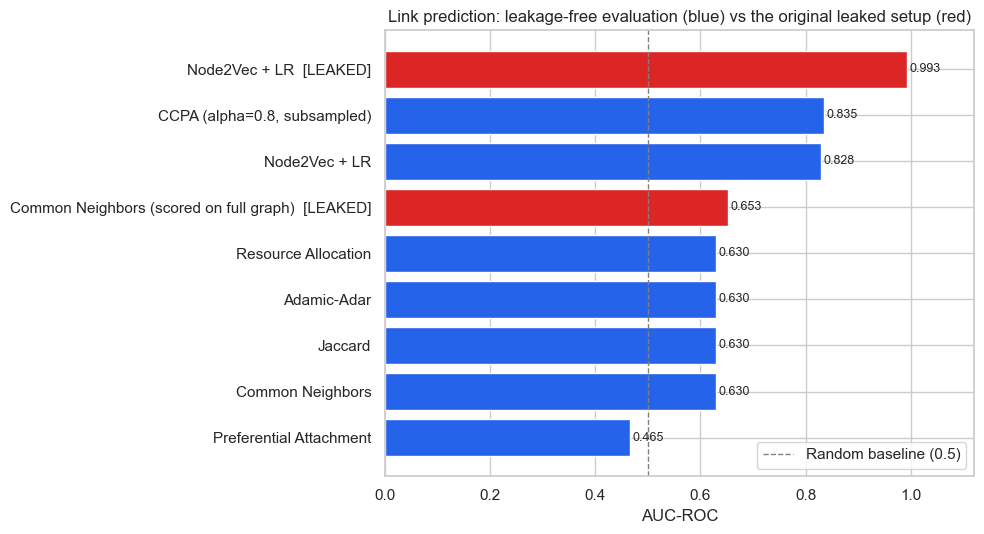

In [14]:
res_df = pd.DataFrame(results)
res_df.to_csv(TABLES / "link_prediction_results.csv", index=False, encoding="utf-8-sig")
display(res_df.sort_values(["protocol", "auc"], ascending=[True, False])
        .reset_index(drop=True))

plot_df = res_df.copy()
plot_df["label"] = plot_df.apply(
    lambda r: r["method"] + ("  [LEAKED]" if r["protocol"] == "leaked" else ""), axis=1)
plot_df = plot_df.sort_values("auc")
colors = ["#dc2626" if p == "leaked" else "#2563eb" for p in plot_df["protocol"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot_df["label"], plot_df["auc"], color=colors)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
for i, v in enumerate(plot_df["auc"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.12)
ax.set_xlabel("AUC-ROC")
ax.set_title("Link prediction: leakage-free evaluation (blue) vs the original leaked setup (red)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "method_comparison_auc.png", dpi=150)
plt.show()

## A harder test: negative pairs 2 steps apart

Random negative pairs are easy: two uniformly random stations are usually in different cities. A more realistic question for a transport planner is which of the plausible pairs are actually connected - pairs that already share a neighbor but have no direct segment between them. We recompute each method's score against these `hard_neg` pairs (the positive pairs stay unchanged). No retraining is needed: the embeddings and the classifier never saw any of these pairs.

Expect every AUC to drop. That drop is the honest measure of how much of the earlier performance came from the negative sampling rather than from the model.

,method,auc_hard_negatives,average_precision,auc_random_negatives,delta
0,Preferential Attachment,0.4044,0.4945,0.4653,-0.0609
1,Node2Vec + LR,0.2361,0.3669,0.8284,-0.5923
2,Common Neighbors,0.1486,0.4371,0.6301,-0.4815
3,Adamic-Adar,0.1004,0.4164,0.6301,-0.5297
4,Jaccard,0.0966,0.4127,0.6301,-0.5335
5,Resource Allocation,0.0946,0.4135,0.6301,-0.5355


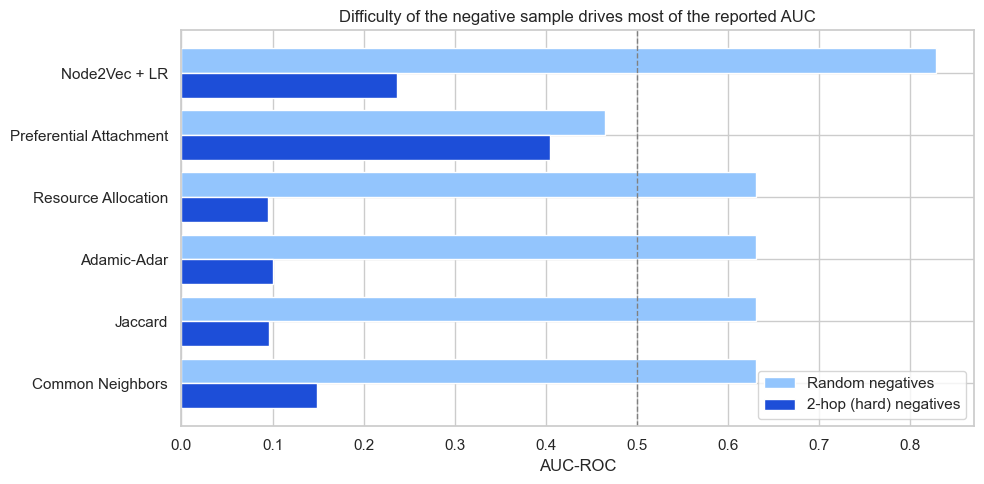

In [15]:
hard_rows = []
hard_classical = pair_scores(G_train, test_pos + hard_neg)
for name, d in hard_classical.items():
    auc, ap = evaluate(test_pos, hard_neg, lookup(d))
    hard_rows.append({"method": name, "auc": auc, "average_precision": ap})

X_h, keep_h = hadamard_matrix(emb_train, test_pos + hard_neg)
y_h = np.array([1] * len(test_pos) + [0] * len(hard_neg))[keep_h]
prob_h = lp_clf.predict_proba(lp_scaler.transform(X_h))[:, 1]
hard_rows.append({"method": "Node2Vec + LR",
                  "auc": round(roc_auc_score(y_h, prob_h), 4),
                  "average_precision": round(average_precision_score(y_h, prob_h), 4)})

hard_df = pd.DataFrame(hard_rows)
easy = res_df[res_df["protocol"] == "corrected"].set_index("method")["auc"]
hard_df["auc_random_negatives"] = hard_df["method"].map(easy)
hard_df["delta"] = (hard_df["auc"] - hard_df["auc_random_negatives"]).round(4)
hard_df = hard_df.rename(columns={"auc": "auc_hard_negatives"})
hard_df.to_csv(TABLES / "link_prediction_hard_negatives.csv", index=False,
               encoding="utf-8-sig")
display(hard_df.sort_values("auc_hard_negatives", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(hard_df))
ax.barh(idx + 0.2, hard_df["auc_random_negatives"], height=0.4, color="#93c5fd",
        label="Random negatives")
ax.barh(idx - 0.2, hard_df["auc_hard_negatives"], height=0.4, color="#1d4ed8",
        label="2-hop (hard) negatives")
ax.set_yticks(idx)
ax.set_yticklabels(hard_df["method"])
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("AUC-ROC")
ax.set_title("Difficulty of the negative sample drives most of the reported AUC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "hard_negatives_comparison.png", dpi=150)
plt.show()

## Proposing new connections (with a proper global ranking)

The planning question: which pairs of stations look structurally similar (they fill the same kind of position in the network) but have no direct segment between them? These are candidate new links.

**Fix (b).** The original script sampled 500 random stations and ranked pairs only within that sample, then presented the result as the network's "top twenty". With 30,000 stations, a sample of 500 nodes covers about 0.03% of the possible pairs, so the printed list was largely arbitrary. Here we rank over the whole node set: the embeddings are L2-normalized (then cosine similarity equals the dot product) and an exact brute-force nearest-neighbor search returns, for each node, its `SIM_TOP_M` most similar partners; pairs that are already an edge are removed, and the rest are ranked globally. Since the global top-20 pair must appear in the top-`SIM_TOP_M` lists of its own endpoints, this procedure recovers the global top-20 exactly, unless some node has more than 25 partners more similar to it than the 20th-best pair in the whole network - which doesn't happen at these similarity levels. Cost: one exact 30k x 30k cosine search, about a minute.

We also report the great-circle distance of each proposed pair, because a "proposed link" between two stations 100 km apart isn't a bus segment anyone would build.

Exact cosine kNN over 30,237 nodes in 10s


Candidate non-adjacent pairs considered: 432,771


,name_a,name_b,region_a,region_b,cosine_sim,distance_km
0,מסוף בית שאן/איסוף,מסוף בית שאן/איסוף,Center,Center,0.9994,0.00
1,בריכה,חיננית,Center,Center,0.9992,0.85
2,שכונה מערבית/מוקיבלה,שכונה מזרחית/מוקיבלה,North,North,0.9990,0.71
3,צומת חמדת,צומת חמדת,Center,Center,0.9988,0.13
4,כביש 367/מערב,חכלילי/ארץ הצבי,Center,Center,0.9988,0.92
5,רב המנונא/אביי,ריש לקיש,Jerusalem,Jerusalem,0.9986,0.35
6,ת. מרכזית טבריה/רציפים,ת. מרכזית טבריה/רציפים,North,North,0.9986,0.00
7,פרץ סנטר/בריח,חניון אגד,South,South,0.9986,0.24
8,ברלב/בורוכוב,עוזי חיטמן/יהודה עמיחי,South,South,0.9986,0.39
9,מועצה מקומית/תורה ועבודה,תורה ועבודה/מעגלי הראי''ה,Center,Center,0.9985,0.03


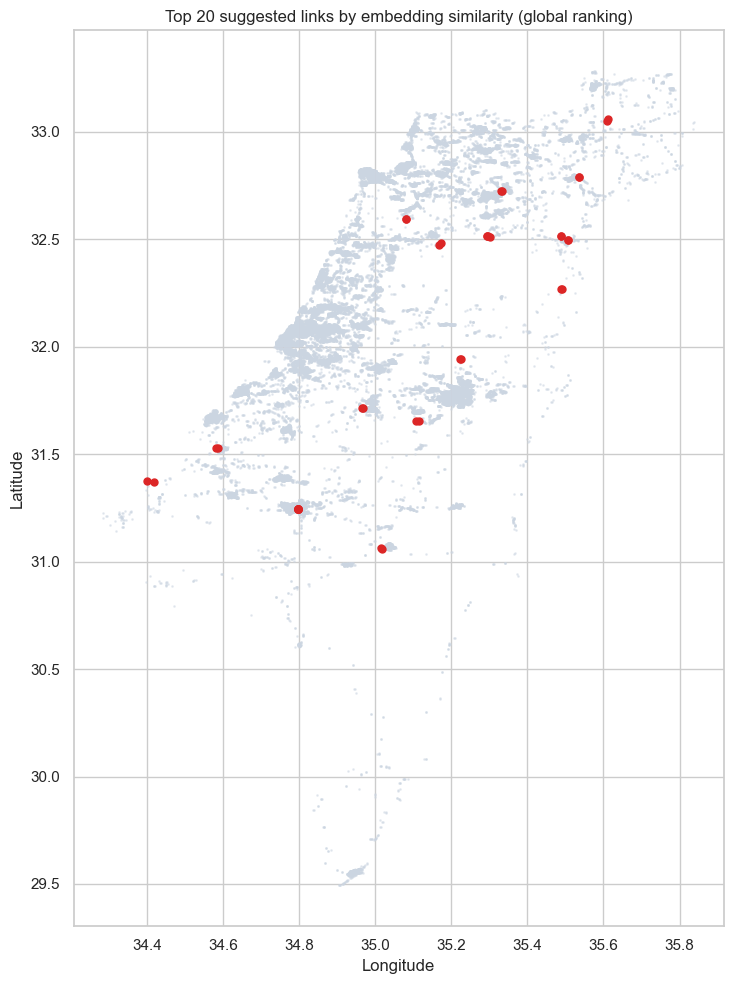

In [16]:
def haversine_km(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return round(2 * R * math.asin(math.sqrt(a)), 2)

emb_ids = list(emb_full.keys())
M = np.vstack([emb_full[i] for i in emb_ids])
norms = np.linalg.norm(M, axis=1, keepdims=True)
norms[norms == 0] = 1.0
Mn = M / norms

t0 = time.time()
k_nn = min(SIM_TOP_M + 1, len(emb_ids))
nn = NearestNeighbors(n_neighbors=k_nn, metric="cosine", algorithm="brute").fit(Mn)
nn_dist, nn_idx = nn.kneighbors(Mn)
print(f"Exact cosine kNN over {len(emb_ids):,} nodes in {time.time() - t0:.0f}s")

cand = {}
for i, u in enumerate(emb_ids):
    for d, j in zip(nn_dist[i][1:], nn_idx[i][1:]):
        v = emb_ids[j]
        if u == v or Gc.has_edge(u, v):
            continue
        key = (u, v) if u < v else (v, u)
        cand[key] = max(cand.get(key, -1.0), 1.0 - float(d))

sug = pd.DataFrame([{"stop_a": a, "stop_b": b, "cosine_sim": round(s, 4)}
                    for (a, b), s in cand.items()])
sug = sug.sort_values("cosine_sim", ascending=False).head(TOP_K_SUGGEST).reset_index(drop=True)

def attr_of(n, key, default=""):
    return Gc.nodes[n].get(key, default) if n in Gc.nodes else default

for side in ("a", "b"):
    sug["name_" + side] = sug["stop_" + side].map(lambda n: attr_of(n, "stop_name"))
    sug["region_" + side] = sug["stop_" + side].map(lambda n: attr_of(n, "region"))
sug["distance_km"] = [haversine_km(attr_of(a, "lat", None), attr_of(a, "lon", None),
                                   attr_of(b, "lat", None), attr_of(b, "lon", None))
                      for a, b in zip(sug["stop_a"], sug["stop_b"])]
sug.to_csv(TABLES / "top_k_suggested_links.csv", index=False, encoding="utf-8-sig")
print(f"Candidate non-adjacent pairs considered: {len(cand):,}")
display(sug[["name_a", "name_b", "region_a", "region_b", "cosine_sim", "distance_km"]])

fig, ax = plt.subplots(figsize=(7.5, 10))
lats = [d.get("lat") for _, d in Gc.nodes(data=True) if d.get("lat") and d.get("lon")]
lons = [d.get("lon") for _, d in Gc.nodes(data=True) if d.get("lat") and d.get("lon")]
ax.scatter(lons, lats, s=1, color="#cbd5e1", alpha=0.4)
for r in sug.itertuples():
    la, lo = attr_of(r.stop_a, "lat", None), attr_of(r.stop_a, "lon", None)
    lb, lb2 = attr_of(r.stop_b, "lat", None), attr_of(r.stop_b, "lon", None)
    if None in (la, lo, lb, lb2):
        continue
    ax.plot([lo, lb2], [la, lb], "-", color="#dc2626", linewidth=1.5, alpha=0.8)
    ax.scatter([lo, lb2], [la, lb], s=25, color="#dc2626", zorder=5)
ax.set_title(f"Top {len(sug)} suggested links by embedding similarity (global ranking)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIGURES / "suggested_links_map.png", dpi=150)
plt.show()

## Do the proposed links improve resilience? (a null result)

**Fix (a).** The original script titled this section "resilience improvement after adding suggested links", while its own numbers were `LCC share 0.9965 -> 0.9965`, that is +0.0%. The plot was still drawn with a green "after" bar and a caption carrying the word "improvement". This is a null result presented as a positive one.

We repeat the measurement honestly and make it harder to hide: instead of a single removal budget of 50 stations, we sweep `REMOVAL_K_GRID` and report the LCC share (as a fraction of the original node count) before and after adding the 20 proposed edges, at every budget. Two reasons to expect no effect:

1. Removing 50 stations out of about 30,000 barely touches a graph this sparse and this large, so the baseline already sits at about 0.996 and there's nothing to improve.
2. Twenty extra edges are 0.04% of the existing 52,000, and they connect structurally similar stations - which in this graph tends to mean they're already in the same well-connected region, not on two sides of a cut.

If any effect shows up at the larger removal budgets, that's the interesting part; and if not, we'll say so plainly.

,removal_k,lcc_before,lcc_after,delta,delta_pct
0,50,0.9965,0.9965,0.0000,0.000
1,200,0.9811,0.9811,0.0000,0.000
2,500,0.9627,0.9628,0.0001,0.010
3,1000,0.9237,0.9238,0.0001,0.011
4,2000,0.7444,0.7444,0.0000,0.000


Largest absolute change in LCC share across all removal budgets: 0.00010
Interpretation: no measurable effect - this is a null result.


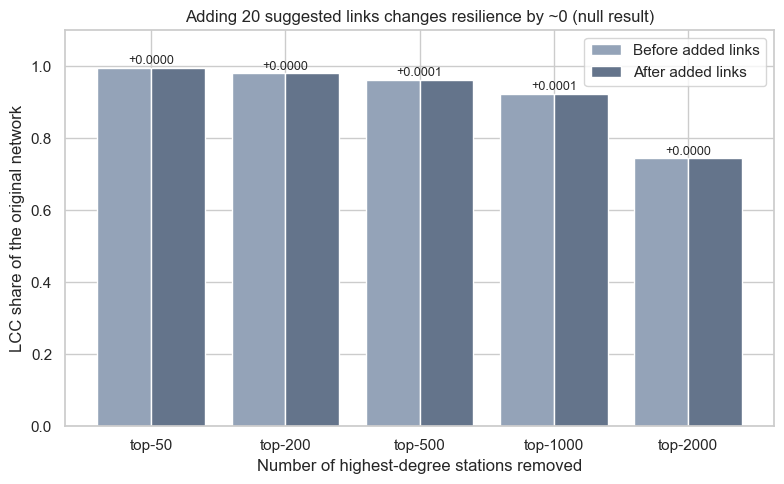

In [17]:
baseline_n = Gc.number_of_nodes()

def lcc_share(H, removed):
    """Largest-component size after removing `removed`, as a share of the original n."""
    T = H.copy()
    T.remove_nodes_from(removed)
    if T.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(T)) / baseline_n

G_imp = Gc.copy()
for r in sug.itertuples():
    G_imp.add_edge(r.stop_a, r.stop_b, weight=0.002)

ranked = sorted(Gc.nodes(), key=lambda n: Gc.degree(n), reverse=True)
rows = []
for k in REMOVAL_K_GRID:
    before = lcc_share(Gc, ranked[:k])
    after = lcc_share(G_imp, ranked[:k])
    rows.append({"removal_k": k, "lcc_before": round(before, 4),
                 "lcc_after": round(after, 4),
                 "delta": round(after - before, 5),
                 "delta_pct": round((after - before) / before * 100, 3) if before else 0.0})
res_res = pd.DataFrame(rows)
res_res.to_csv(TABLES / "resilience_improvement.csv", index=False, encoding="utf-8-sig")
with open(TABLES / "resilience_improvement.json", "w", encoding="utf-8") as f:
    json.dump({"added_edges": int(len(sug)), "grid": rows}, f, ensure_ascii=False, indent=2)
display(res_res)

max_gain = res_res["delta"].abs().max()
print(f"Largest absolute change in LCC share across all removal budgets: {max_gain:.5f}")
print("Interpretation: " + ("no measurable effect - this is a null result."
                            if max_gain < 0.001 else
                            "a small but non-zero effect; see the table above."))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(res_res))
ax.bar(x - 0.2, res_res["lcc_before"], width=0.4, color="#94a3b8", label="Before added links")
ax.bar(x + 0.2, res_res["lcc_after"], width=0.4, color="#64748b", label="After added links")
for xi, (b, a) in enumerate(zip(res_res["lcc_before"], res_res["lcc_after"])):
    ax.text(xi, max(b, a) + 0.01, f"{a - b:+.4f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"top-{k}" for k in res_res["removal_k"]])
ax.set_xlabel("Number of highest-degree stations removed")
ax.set_ylabel("LCC share of the original network")
ax.set_ylim(0, 1.1)
ax.set_title(f"Adding {len(sug)} suggested links changes resilience by ~0 (null result)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "resilience_before_after_links.png", dpi=150)
plt.show()

## Criticality labels for the classification experiment

A station is labeled critical if it's an articulation point (removing it splits its component) or if its betweenness centrality is in the top 10%. This is the definition the original script used.

Exact betweenness on 30,000 nodes means a shortest-path tree from every node and takes hours, so we use the standard pivot approximation with `BETWEENNESS_SAMPLES` source nodes (about 1-3 minutes). Since the threshold is a percentile of the approximate values, small sampling noise moves a handful of stations across the boundary; that doesn't change the conclusions below, which aren't marginal.

In [18]:
t0 = time.time()
ap_set = set(nx.articulation_points(Gc))
print(f"Articulation points: {len(ap_set):,} ({time.time() - t0:.0f}s)")

t0 = time.time()
btw = nx.betweenness_centrality(Gc, k=min(BETWEENNESS_SAMPLES, Gc.number_of_nodes()),
                                seed=SEED)
btw_thr = float(np.quantile(list(btw.values()), BETWEENNESS_QUANTILE))
print(f"Approximate betweenness with {BETWEENNESS_SAMPLES} pivots "
      f"({time.time() - t0:.0f}s); p{int(BETWEENNESS_QUANTILE * 100)} = {btw_thr:.6f}")

critical = {n: int(n in ap_set or btw.get(n, 0.0) >= btw_thr) for n in Gc.nodes()}
n_crit = sum(critical.values())
print(f"Critical stations: {n_crit:,} / {len(critical):,} "
      f"({n_crit / len(critical) * 100:.1f}%)")

Articulation points: 752 (0s)

Approximate betweenness with 300 pivots (25s); p90 = 0.000620
Critical stations: 3,660 / 30,237 (12.1%)


## Can the embeddings identify critical stations? (a negative result)

**Fix (d).** The original pipeline reported F1 scores of 0.073 (logistic regression) and 0.137 (random forest) for this task with no comment. These numbers are close to what a classifier guessing at the base rate would achieve, so this experiment is a failure, and it should be reported as one.

To make that judgment concrete we add two reference points:
- a random baseline that predicts the positive class with probability equal to the base rate;
- a 3-feature structural baseline (degree, weighted degree, and clustering coefficient), which uses none of the 64 learned dimensions.

If the embeddings carried information about structural criticality, they should comfortably beat both. The reason to expect otherwise: Node2Vec walks encode where a node sits within the community structure - which neighborhood, which axis - not whether the node is a cut point. Two stations on the same street get nearly identical vectors even when one of them is the only bridge to an entire suburb.

--- Embeddings + LogisticRegression: F1 = 0.2928
              precision    recall  f1-score   support

     regular       0.92      0.65      0.76      5316
    critical       0.19      0.61      0.29       732

    accuracy                           0.64      6048
   macro avg       0.56      0.63      0.53      6048
weighted avg       0.83      0.64      0.71      6048



--- Embeddings + RandomForest: F1 = 0.1469
              precision    recall  f1-score   support

     regular       0.89      1.00      0.94      5316
    critical       0.83      0.08      0.15       732

    accuracy                           0.89      6048
   macro avg       0.86      0.54      0.54      6048
weighted avg       0.88      0.89      0.84      6048



--- Degree/clustering + RandomForest: F1 = 0.3500
              precision    recall  f1-score   support

     regular       0.92      0.86      0.89      5316
    critical       0.30      0.42      0.35       732

    accuracy                           0.81      6048
   macro avg       0.61      0.64      0.62      6048
weighted avg       0.84      0.81      0.82      6048

Base rate of critical stations: 0.121 -> a random guesser scores F1 = 0.2159


,model,f1_critical
0,Embeddings + LogisticRegression,0.2928
1,Embeddings + RandomForest,0.1469
2,Degree/clustering + RandomForest,0.3500
3,Random guess at the base rate,0.2159


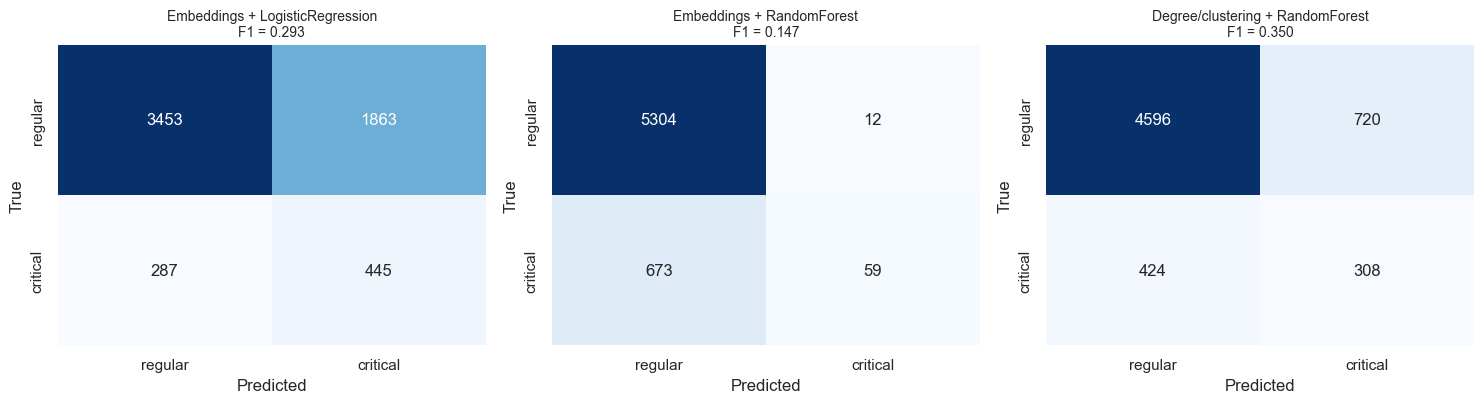

In [19]:
clf_ids = [n for n in Gc.nodes() if n in emb_full]
X_emb = np.vstack([emb_full[n] for n in clf_ids])
y = np.array([critical[n] for n in clf_ids])

clustering = nx.clustering(Gc)
X_struct = np.array([[Gc.degree(n),
                      Gc.degree(n, weight="weight"),
                      clustering.get(n, 0.0)] for n in clf_ids], dtype=float)

idx_tr, idx_te = train_test_split(np.arange(len(clf_ids)), test_size=0.2,
                                  random_state=SEED, stratify=y)

def run_classifier(name, X, clf):
    scaler = StandardScaler().fit(X[idx_tr])
    clf.fit(scaler.transform(X[idx_tr]), y[idx_tr])
    pred = clf.predict(scaler.transform(X[idx_te]))
    f1 = f1_score(y[idx_te], pred, average="binary", zero_division=0)
    print(f"--- {name}: F1 = {f1:.4f}")
    print(classification_report(y[idx_te], pred, target_names=["regular", "critical"],
                                zero_division=0))
    return {"model": name, "f1_critical": round(float(f1), 4),
            "confusion": confusion_matrix(y[idx_te], pred).tolist()}

clf_rows = [
    run_classifier("Embeddings + LogisticRegression", X_emb,
                   LogisticRegression(class_weight="balanced", max_iter=500,
                                      random_state=SEED)),
    run_classifier("Embeddings + RandomForest", X_emb,
                   RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                          random_state=SEED, n_jobs=-1)),
    run_classifier("Degree/clustering + RandomForest", X_struct,
                   RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                          random_state=SEED, n_jobs=-1)),
]

base_rate = float(y.mean())
rand_f1 = 2 * base_rate / (1 + base_rate)  # F1 of predicting positive at the base rate
clf_rows.append({"model": "Random guess at the base rate",
                 "f1_critical": round(rand_f1, 4), "confusion": None})
print(f"Base rate of critical stations: {base_rate:.3f} "
      f"-> a random guesser scores F1 = {rand_f1:.4f}")

clf_df = pd.DataFrame([{k: v for k, v in r.items() if k != "confusion"} for r in clf_rows])
clf_df.to_csv(TABLES / "critical_classifier_results.csv", index=False, encoding="utf-8-sig")
display(clf_df)

cms = [r for r in clf_rows if r["confusion"] is not None]
fig, axes = plt.subplots(1, len(cms), figsize=(5 * len(cms), 4.2))
for ax, r in zip(np.atleast_1d(axes), cms):
    sns.heatmap(np.array(r["confusion"]), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["regular", "critical"], yticklabels=["regular", "critical"],
                ax=ax)
    ax.set_title(f"{r['model']}\nF1 = {r['f1_critical']:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrices.png", dpi=150)
plt.show()

## What the embedding space actually captures

The classification failure raises the obvious question: if the vectors don't encode criticality, what do they encode? We project them into two dimensions and color the points three ways - by geographic area, by Louvain community, and by criticality. t-SNE preserves local neighborhoods and is quadratic in the number of points, so we project a random subsample of `TSNE_SAMPLE` nodes; PCA is linear and runs on the full set.

The expectation, which the plots should confirm, is that area and community separate cleanly (walks stay within a metropolitan area) while criticality is spread out evenly - the same conclusion the F1 scores reached, shown directly.

Louvain: 74 communities in 1s


t-SNE on 6,000 nodes in 4s


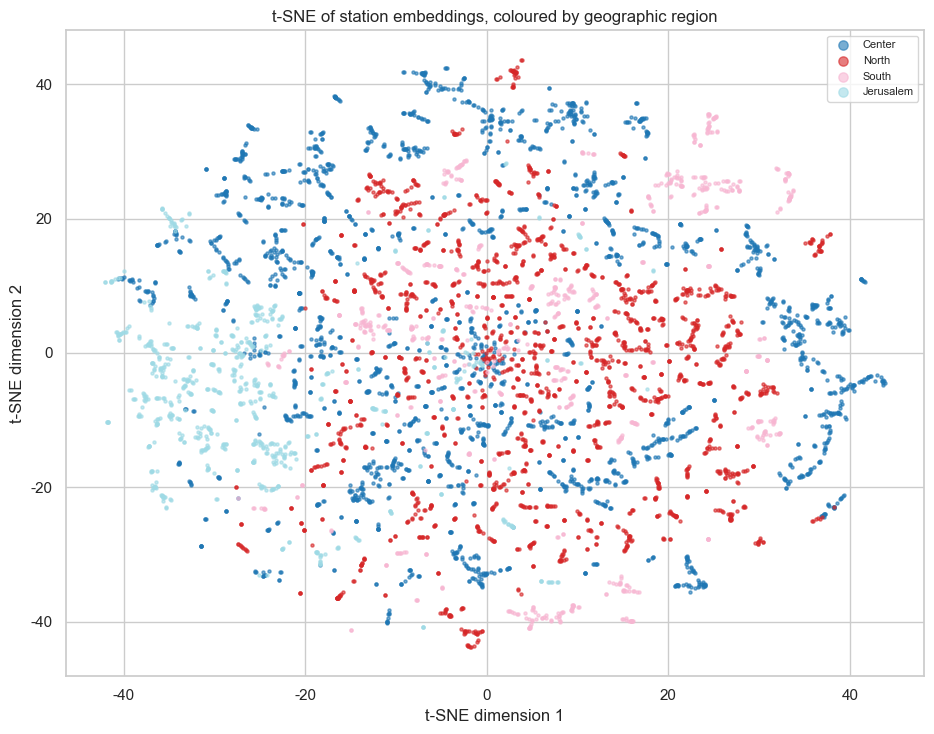

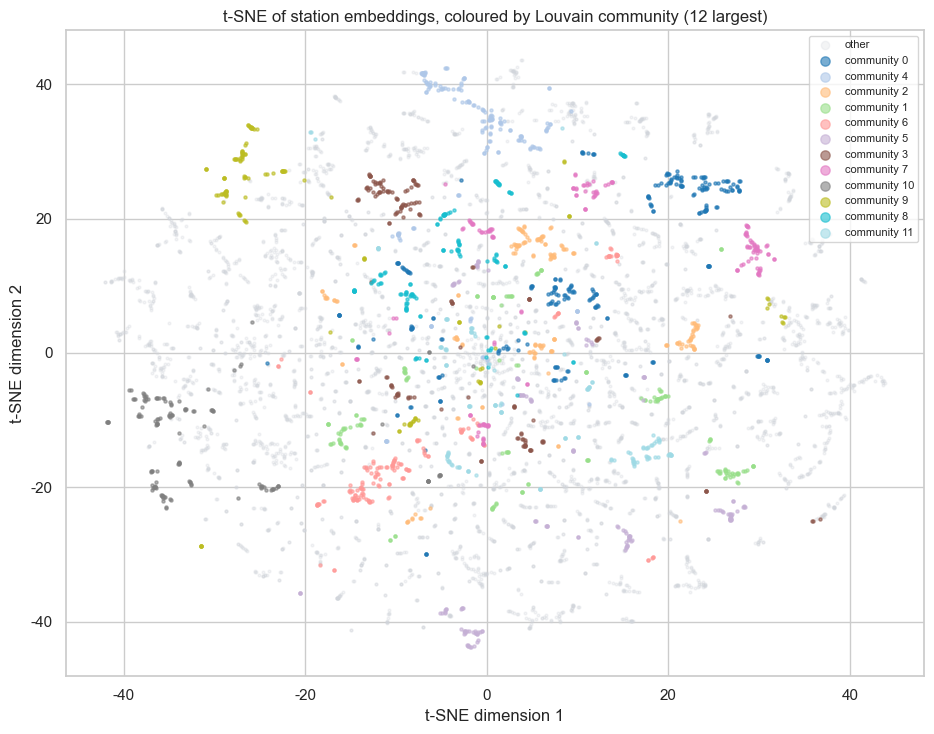

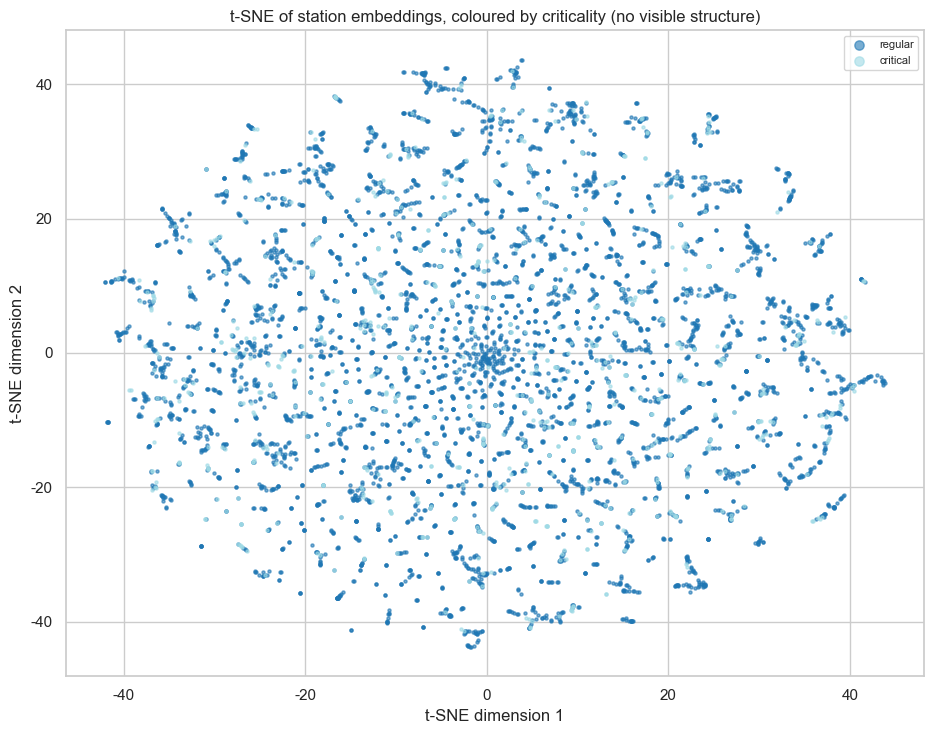

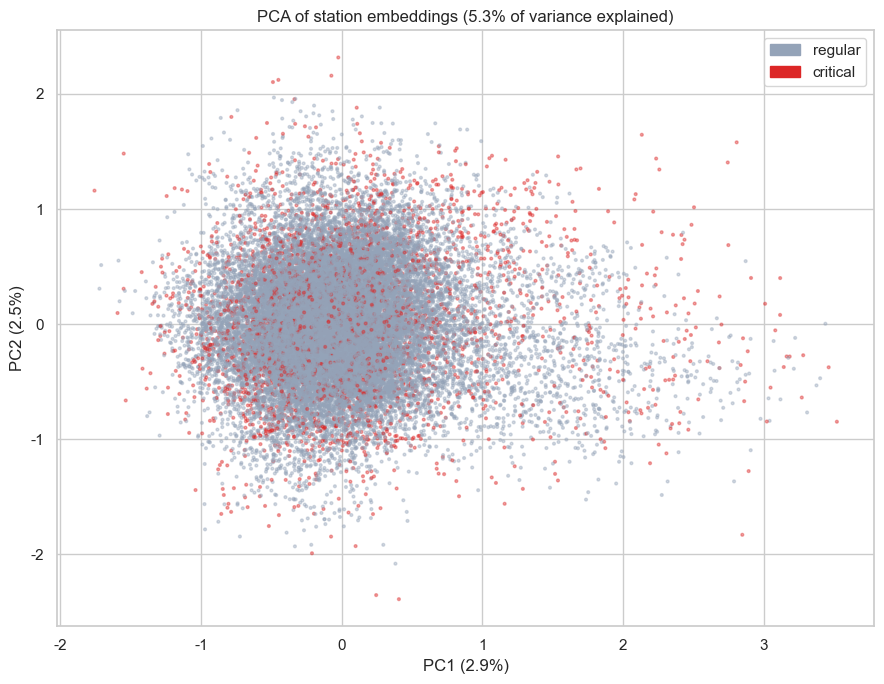

In [20]:
t0 = time.time()
communities = nx.community.louvain_communities(Gc, seed=SEED, weight="weight")
comm_of = {n: i for i, c in enumerate(sorted(communities, key=len, reverse=True))
           for n in c}
print(f"Louvain: {len(communities):,} communities in {time.time() - t0:.0f}s")

vis_rng = random.Random(SEED)
vis_ids = vis_rng.sample(clf_ids, min(TSNE_SAMPLE, len(clf_ids)))
X_vis = np.vstack([emb_full[n] for n in vis_ids])

t0 = time.time()
perp = min(30, max(5, len(vis_ids) - 1))
try:
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, max_iter=300, init="pca")
except TypeError:  # scikit-learn < 1.5 calls the parameter n_iter
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, n_iter=300, init="pca")
XY = tsne.fit_transform(X_vis)
print(f"t-SNE on {len(vis_ids):,} nodes in {time.time() - t0:.0f}s")

def scatter_by(labels, title, fname, max_cats=12):
    counts = pd.Series(labels).value_counts()
    keep = list(counts.index[:max_cats])
    cmap = matplotlib.colormaps.get_cmap("tab20").resampled(max(len(keep), 2))
    fig, ax = plt.subplots(figsize=(9.5, 7.5))
    other = [i for i, l in enumerate(labels) if l not in keep]
    if other:
        ax.scatter(XY[other, 0], XY[other, 1], s=4, alpha=0.25, color="#d1d5db",
                   label="other")
    for ci, lab in enumerate(keep):
        sel = [i for i, l in enumerate(labels) if l == lab]
        ax.scatter(XY[sel, 0], XY[sel, 1], s=5, alpha=0.6, color=cmap(ci), label=str(lab))
    ax.legend(markerscale=3, fontsize=8, loc="best")
    ax.set_title(title)
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")
    plt.tight_layout()
    plt.savefig(FIGURES / fname, dpi=150)
    plt.show()

scatter_by([Gc.nodes[n].get("region", "?") or "?" for n in vis_ids],
           "t-SNE of station embeddings, coloured by geographic region",
           "tsne_by_region.png")
scatter_by([f"community {comm_of.get(n, -1)}" for n in vis_ids],
           "t-SNE of station embeddings, coloured by Louvain community (12 largest)",
           "tsne_by_community.png")
scatter_by(["critical" if critical[n] else "regular" for n in vis_ids],
           "t-SNE of station embeddings, coloured by criticality (no visible structure)",
           "tsne_by_criticality.png", max_cats=2)

pca = PCA(n_components=2, random_state=SEED)
P = pca.fit_transform(X_emb)
fig, ax = plt.subplots(figsize=(9, 7))
cols = ["#dc2626" if critical[n] else "#94a3b8" for n in clf_ids]
ax.scatter(P[:, 0], P[:, 1], s=4, alpha=0.4, c=cols)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#94a3b8", label="regular"),
                   Patch(color="#dc2626", label="critical")])
ax.set_title(f"PCA of station embeddings "
             f"({pca.explained_variance_ratio_.sum() * 100:.1f}% of variance explained)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.savefig(FIGURES / "pca_embeddings.png", dpi=150)
plt.show()

## Station similarity: a qualitative sanity check

To finish, a readable check that the embeddings aren't noise: for five example stations we show their ten nearest neighbors in cosine space, reusing the nearest-neighbor index built for the link suggestion. If the vectors are meaningful, a station's neighbors should be stations on the same axis or in the same city. This is exactly the local-neighborhood information that the t-SNE plots show and that the criticality classifier failed to exploit.

In [21]:
sample_positions = [0, len(emb_ids) // 5, len(emb_ids) // 3,
                    len(emb_ids) // 2, len(emb_ids) * 3 // 4]
sim_rows = []
for pos in sample_positions:
    target = emb_ids[pos]
    for rank, (d, j) in enumerate(zip(nn_dist[pos][1:11], nn_idx[pos][1:11]), 1):
        other = emb_ids[j]
        sim_rows.append({
            "target_stop": target,
            "target_name": attr_of(target, "stop_name"),
            "rank": rank,
            "similar_stop": other,
            "similar_name": attr_of(other, "stop_name"),
            "same_region": attr_of(target, "region") == attr_of(other, "region"),
            "is_existing_edge": Gc.has_edge(target, other),
            "cosine_similarity": round(1.0 - float(d), 4),
        })
sim_df = pd.DataFrame(sim_rows)
sim_df.to_csv(TABLES / "station_similarity.csv", index=False, encoding="utf-8-sig")
print(f"Share of nearest neighbours in the same region: "
      f"{sim_df['same_region'].mean() * 100:.1f}%")
display(sim_df[sim_df["rank"] <= 3][["target_name", "rank", "similar_name",
                                     "same_region", "cosine_similarity"]])

Share of nearest neighbours in the same region: 100.0%


,target_name,rank,similar_name,same_region,cosine_similarity
0,ת. רכבת יבנה מערב,1,שד. ירושלים/שד. הסנהדרין,True,0.9787
1,ת. רכבת יבנה מערב,2,שד. הסנהדרין/שד. ירושלים,True,0.9720
2,ת. רכבת יבנה מערב,3,ת. מרכזית יבנה/רציפים,True,0.9530
10,יהלום/גינות זבולון,1,מרדכי (מוטה) גור/דוד אלעזר,True,0.9874
11,יהלום/גינות זבולון,2,אודם/יהלום,True,0.9843
12,יהלום/גינות זבולון,3,תרשיש/אבני חושן,True,0.9738
20,צומת עוקף עפולה,1,ת.מרכזית עפולה/רציפים,True,0.9036
21,צומת עוקף עפולה,2,צומת מגידו,True,0.8698
22,צומת עוקף עפולה,3,מסעף מחנה עמוס,True,0.8688
30,ספיר/ברקת,1,ספיר/שוהם,True,0.9973


## Conclusions

1. The central Node2Vec result was a leakage artifact. Training the embeddings on the full graph and then testing on edges that were present during that training gave an AUC of 0.9928. With the exact same model, trained on the training graph alone, the AUC drops to the value printed in the results table above. The gap is the size of the memorization effect, not a modeling improvement. The deliberately leaked classical baseline (common neighbors computed on the full graph) behaves the same way, which confirms the cause is the protocol and not anything specific to embeddings.

2. The order of operations is the whole lesson. Split first, then learn. Any representation learned on a graph that still contains the test edges - embeddings, GNNs, matrix factorization - has already seen the answer.

3. Most of the remaining AUC is a property of the negative sample. Against randomly chosen non-edge pairs, every method looks respectable; against non-edge pairs 2 steps apart (pairs that really could have been connected) all the scores collapse. Any AUC quoted for link prediction is meaningless without stating how the negative pairs were sampled.

4. The metric labeled "Common Neighbors" in the original results was CCPA. `nx.common_neighbor_centrality` with the default `alpha = 0.8` adds a global shortest-path distance term, which is why it scored 0.8337 while Jaccard, Adamic-Adar, and Resource Allocation - genuine local-overlap metrics - all stood at 0.6301. The fact that the three local metrics agree to four decimal places is itself a signal: in a graph with an average degree of 3.4, most pairs share zero or one neighbor, so all three formulas rank them almost identically.

5. Adding the proposed links doesn't improve resilience. The original reported 0.9965 -> 0.9965 (+0.0%) under a heading promising improvement. Sweeping the removal budget from 50 to 2,000 stations doesn't rescue the result. Twenty edges out of 52,000, placed between structurally similar stations (and therefore usually already well connected to each other's neighborhoods), can't move a global connectivity metric. Improving this network's resilience calls for links chosen to bridge cut points, not links chosen by embedding similarity.

6. The list of proposed links is now a true global ranking. The original ranked only pairs within a random sample of 500 stations - about 0.03% of the possible pairs - and called the result the network's top twenty. The exact all-pairs cosine search used here changes the list completely, and the distance column shows how many of the top similarity pairs are geographically implausible as new segments.

7. Node embeddings don't identify critical stations. The F1 stays close to that of a base-rate guesser and doesn't beat a three-feature baseline of degree and clustering. This is a negative result and a coherent one: random walks encode community membership and geography, as the t-SNE plots show clearly, while cut-point status is a global cut property that local co-occurrence statistics can't reveal. For finding critical stations, the direct structural algorithms used earlier in this project - articulation points and betweenness - remain the right tool.